In [ ]:
from google.colab import drive #cargar archivo desde el drive.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#importar librerias

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dataset_bootcamp_G611_SUCIO.csv")
df


,ID Venta,Fecha,Cliente,País,Ciudad,Zona,Producto,Tipo de producto,Canal,Unidades,Precio Unitario,Descuento,Importe venta total,Prioridad
0,VTA-0001,17/08/2024,Paula Castro,Venezuela,Valencia,oeste,Smartphone,Móviles,Online,50,2439821.0,0.15,103692392.0,BAJA
1,VTA-0178,02/19/2023,David Flores,Bolivia,La Paz,Sur,Tablet,Computadores,ONLINE,150,1356711.0,0.14,175015719.0,baja
2,VTA-0311,2023/09/12,Nicolás Rojas,México,Guadalajara,Centro,Monitor,Computadores,presencial,89,899.349,0.09,72838276.0,BAJA
3,VTA-0335,23/02/2023,Camila Díaz,Colombia,Bogotá,sur,Cámara Web,Periféricos,Online,18,165108.0,0.23,2288397.0,Crítica
4,VTA-0280,2024/08/26,Camila Díaz,Chile,Valparaíso,ESTE,Router,Redes,ONLINE,73,221626.0,0.29,11486876.0,media
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,VTA-0154,2024/02/18,Carlos Ramírez,Chile,Concepción,Centro,Laptop,Computadores,distribuidor,187,3214839.0,0.30,420822425.0,BAJA
550,VTA-0529,07 Aug 2024,Nicolás Rojas,Ecuador,Quito,CENTRO,Disco Duro,Almacenamiento,distribuidor,172,289982.0,0.03,48380597.0,Critica
551,VTA-0075,01/05/2024,NaN,Perú,Arequipa,Centro,Hub USB,Accesorios,online,96,69793.0,0.01,6633127.0,Media
552,VTA-0177,2023/12/14,felipe jiménez,Uruguay,Paysandú,centro,Tablet,Computadores,Online,194,1358021.0,0.04,252917831.0,NaN


In [ ]:
df.isnull() # devuelve un true si hay  un dato nulo
df.isnull().sum() # devuelve la cantidad de nulos que hay en cada columna

,0
ID Venta,0
Fecha,0
Cliente,12
País,0
Ciudad,17
Zona,42
Producto,0
Tipo de producto,0
Canal,35
Unidades,0


In [ ]:
df.isnull().sum().sum() # devuelve la cantidad de nulos que hay en todo el dataframe

np.int64(227)

In [ ]:
#ver los datos de la columna "zona"
df["Zona"].unique()

array(['oeste', 'Sur', ' Centro ', 'sur', 'ESTE', ' Sur', 'Centro',
       'este', 'norte', nan, 'Norte ', 'Oeste', 'Norte', 'NORTE', 'SUR',
       'centro', ' Norte', 'OESTE', 'Este', 'CENTRO'], dtype=object)

In [ ]:
#con strip borra los espacios atrás y adelante
df["Zona"]=df["Zona"].str.strip()
df["Zona"].unique()

array(['oeste', 'Sur', 'Centro', 'sur', 'ESTE', 'este', 'norte', nan,
       'Norte', 'Oeste', 'NORTE', 'SUR', 'centro', 'OESTE', 'Este',
       'CENTRO'], dtype=object)

In [ ]:
#con upper todas quedan en mayúsculas
df["Zona"]=df["Zona"].str.upper()
df["Zona"].unique()

array(['OESTE', 'SUR', 'CENTRO', 'ESTE', 'NORTE', nan], dtype=object)

In [ ]:
#con capitalize solo la primera letra de la primera palabra queda mayúscula
df["Zona"]=df["Zona"].str.capitalize()
df["Zona"].unique()

array(['Oeste', 'Sur', 'Centro', 'Este', 'Norte', nan], dtype=object)

In [ ]:
#con title la primera letra de cada palabra queda mayúscula
df["Zona"]=df["Zona"].str.title()
df["Zona"].unique()

array(['Oeste', 'Sur', 'Centro', 'Este', 'Norte', nan], dtype=object)

In [ ]:
#Imputar datos faltantes para la "Zona"
df["Zona"]=df["Zona"].fillna("Desconocida")
df["Zona"].unique()

array(['Oeste', 'Sur', 'Centro', 'Este', 'Norte', 'Desconocida'],
      dtype=object)

In [ ]:
#para crear una copia de la base de datos:
df_copia = df.copy()


In [ ]:
df["PRODUCTO"]=df["PRODUCTO"].str.strip()
df["PRODUCTO"]=df["PRODUCTO"].str.capitalize()

KeyError: 'PRODUCTO'

In [ ]:
df_copia["PRODUCTO"].unique()

KeyError: 'PRODUCTO'

In [ ]:
## **¿Por qué renombrar columnas?**
#•Opción 1: Renombrar solo algunas columnas
df.rename(columns= {
    "id_venta" : "id venta",
    "precio_unitario" : "precio unitario"
}, inplace=True)
df

In [ ]:
#•Opción 1: Renombrar todas las columnas, para este caso todas las columnas estarán en mayúsculas.


df.columns = ["ID VENTA", "FECHA", "CLIENTE", "PAÍS",	"CIUDAD",	"ZONA",	"PRODUCTO",	"TIPO DE PRODUCTO",	"CANAL", "UNIDADES", "PRECIO UNITARIO",	"DESCUENTO", "IMPORTE VENTA TOTAL",	"PRIORIDAD"]
df

In [ ]:
#¿Por qué es importante cambiar los tipos de datos?
#convertir texto a número. En este caso había celdas con error, por esa razón el código lo hizo fue.
#Primero corregirlos y luego aplicar lo que se quería.

df["PRECIO UNITARIO"] = pd.to_numeric(df["PRECIO UNITARIO"], errors='coerce')
df["PRECIO UNITARIO"] = df["PRECIO UNITARIO"].fillna(0).astype(float)
df

In [ ]:

#Convertir a fecha


df["FECHA"] = pd.to_datetime(df["FECHA"], format='mixed')
df

In [ ]:
#Eliminar una o más columnas por nombre
df.drop(columns=["ID VENTA"], inplace=True)
df
#

In [ ]:
columns_to_check = ["CLIENTE", "PAÍS", "CIUDAD", "ZONA", "PRODUCTO", "TIPO DE PRODUCTO", "CANAL", "UNIDADES", "PRECIO UNITARIO", "DESCUENTO", "IMPORTE VENTA TOTAL", "PRIORIDAD"]

for col in columns_to_check:
    print(f"Unique values for '{col}':")
    print(df[col].unique())
    print("-" * 30)

In [ ]:
df["CLIENTE"]=df["CLIENTE"].str.title()
df["PAÍS"]=df["PAÍS"].str.title()
df["CANAL"]=df["CANAL"].str.title()
df["PRIORIDAD"]=df["PRIORIDAD"].str.title()
df["ZONA"].unique()

In [ ]:
df.isnull().sum()

In [ ]:
df.info()


In [ ]:
df_sin_nulos = df.dropna() # elimina las columnas  que contiene datos nulos
df_sin_nulos

In [ ]:
df_sin_columnas_nulas = df.dropna(axis=1) # elimina las columnas  que contiene datos nulos
df_sin_columnas_nulas


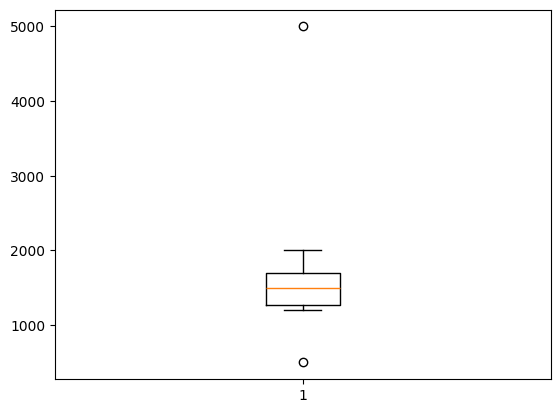

In [ ]:
#Misión 3 ¿Qué es un boxplot?


import matplotlib.pyplot as plt

salarios = [1200, 1500, 1400, 1600, 1550, 1300, 1250, 2000, 1800, 5000, 500]

plt.boxplot(salarios)
plt.show()


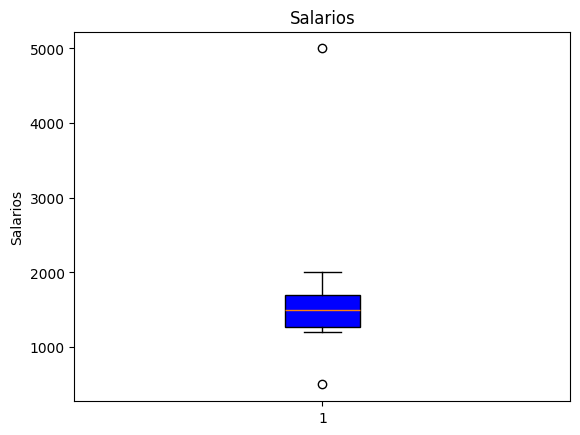

In [ ]:
#Ahora vamos a cambiar algunos parámetros del boxplot.

import matplotlib.pyplot as plt

salarios = [1200, 1500, 1400, 1600, 1550, 1300, 1250, 2000, 1800, 5000, 500]

plt.boxplot(salarios, patch_artist=True, boxprops=dict(facecolor="blue"))
plt.title("Salarios")
plt.ylabel("Salarios")
plt.show()


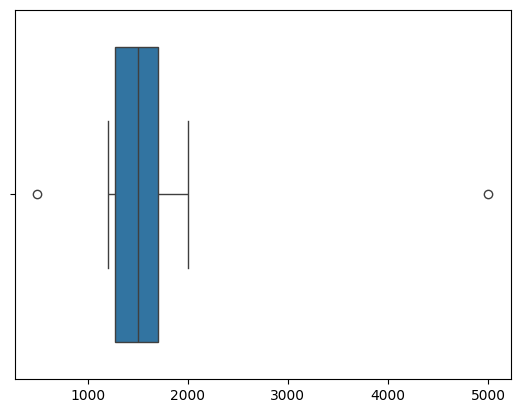

In [ ]:
#Ahora vamos a crear el boxplot, utilizando la librería seaborn.

import seaborn as sns

salarios = [1200, 1500, 1400, 1600, 1550, 1300, 1250, 2000, 1800, 5000, 500]

#Crear boxplot
sns.boxplot(x=salarios)

plt.show()

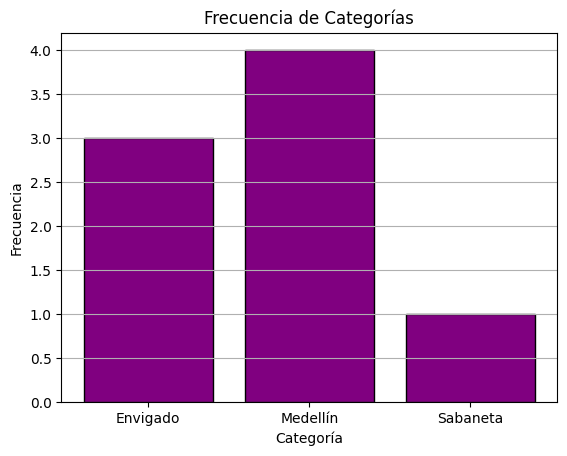

In [ ]:
#Barras con matplotlib



categorias = ["Envigado", "Medellín", "Sabaneta"]
frecuencia = [3, 4, 1]

plt.bar(categorias, frecuencia, color="purple", edgecolor = "black")
plt.title("Frecuencia de Categorías")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.grid(axis="y") #plt.grid(axis="x")  #plt.grid(axis="True")
plt.show()


/tmp/ipykernel_31880/3525142307.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Ciudad", data=df_ciudades, palette="Blues")


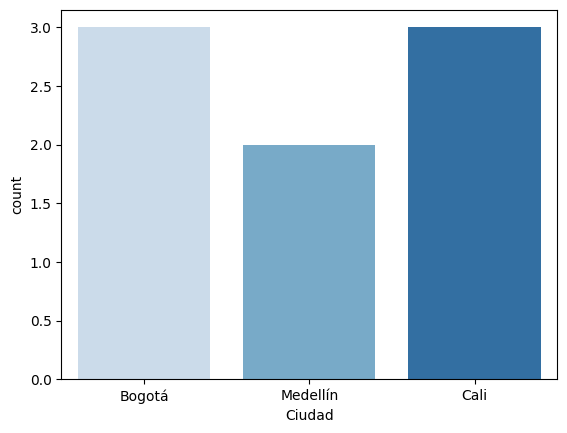

In [ ]:
import pandas as pd
import seaborn as sns


ciudades = ["Bogotá", "Medellín", "Bogotá", "Cali", "Medellín", "Cali", "Bogotá", "Cali"]
df_ciudades = pd.DataFrame({"Ciudad": ciudades})
sns.countplot(x="Ciudad", data=df_ciudades, palette="Blues")
plt.show()

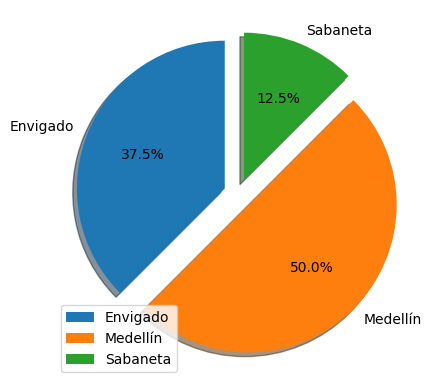

In [ ]:
#Pie Chart con matplotlib

plt.pie(frecuencia, labels=categorias, autopct= "%1.1f%%", explode=(0.1, 0.1, 0.1), shadow=True, startangle=90)
plt.legend(categorias)
plt.show()

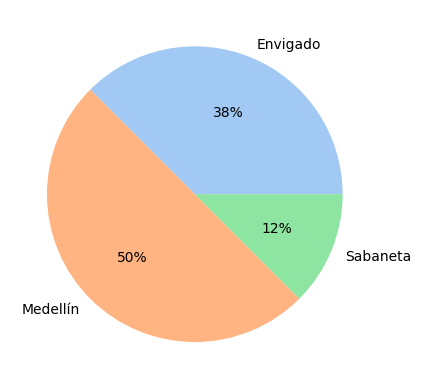

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

import numpy as np

categorias = ["Envigado", "Medellín", "Sabaneta"]
frecuencia = [3, 4, 1]
colors = sns.color_palette('pastel')[0:4]
plt.pie(frecuencia, labels=categorias, colors=colors, autopct='%.0f%%')
plt.show()


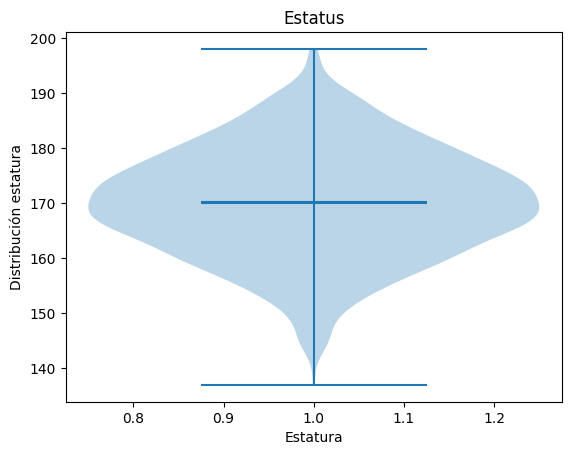

In [ ]:
estaturas = np.random.normal(loc=170, scale=10, size=1000)
plt.violinplot(estaturas, showmeans=True, showmedians=True)
plt.title("Estatus")
plt.xlabel("Estatura")
plt.ylabel("Distribución estatura")
plt.show()

In [ ]:
data = np.radom.normal(loc=170, scale=10, size=100)
df2 = pd.DataFrame({"Estatura": data})
sns.violinplot(x=df2["Estatura"])
#plt.xlabel("Estatus")
plt.ylabel("Estatura")
plt.title("Distribución de Estatura")

plt.show()

AttributeError: module 'numpy' has no attribute 'radom'

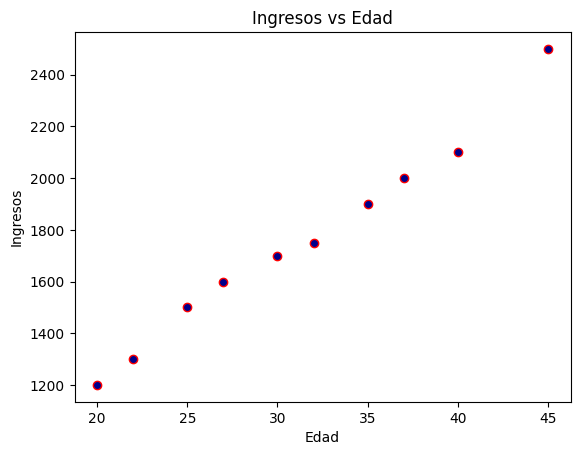

In [ ]:
edad = [ 20, 22, 25, 27, 30, 32, 35, 37, 40, 45]
ingresos = [1200, 1300, 1500, 1600, 1700, 1750, 1900, 2000, 2100, 2500]
plt.scatter(edad, ingresos, color="darkblue", edgecolor="red")
plt.title("Ingresos vs Edad")
plt.xlabel("Edad")
plt.ylabel("Ingresos")
plt.show()
#

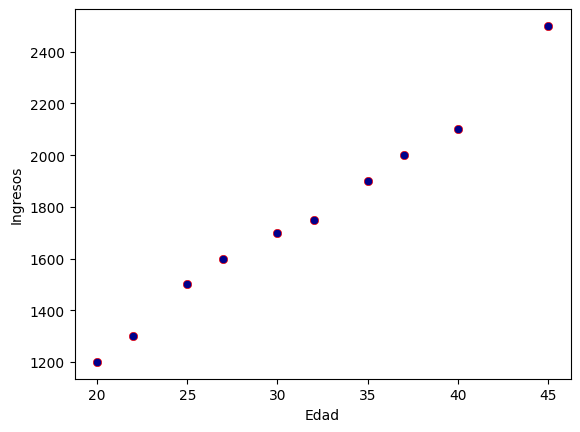

In [ ]:
df3 = pd.DataFrame({"Edad": edad, "Ingresos": ingresos})
sns.scatterplot(data=df3, color="darkblue", edgecolor="red", x="Edad", y="Ingresos")
plt.show()
#

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convierte tu scatterplot en un
# bubble plot

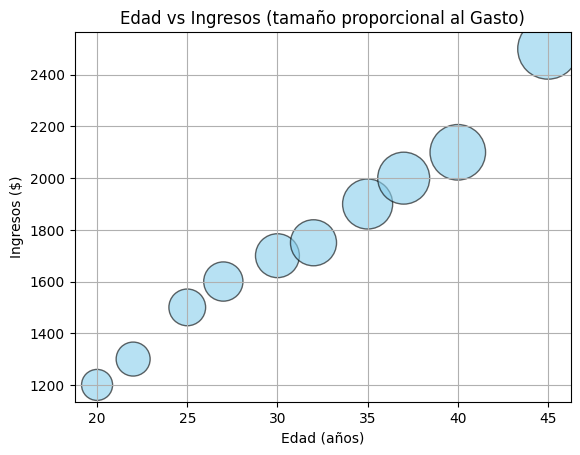

In [ ]:
df = pd.DataFrame({
    "Ingresos": [1200, 1300, 1500, 1600, 1700, 1750, 1900, 2000, 2100, 2500],
    "Edad": [20, 22, 25, 27, 30, 32, 35, 37, 40, 45],
    "Gastos": [500, 600, 700, 800, 1000, 1100, 1300, 1400, 1600, 1900]
})


# Bubble plot com matplotlib
plt.scatter(df["Edad"], df["Ingresos"], s=df["Gastos"], alpha=0.6, color="skyblue", edgecolor="black")

#Personalización
plt.title("Edad vs Ingresos (tamaño proporcional al Gasto)")
plt.xlabel("Edad (años)")
plt.ylabel("Ingresos ($)")
plt.grid(True)
plt.show()

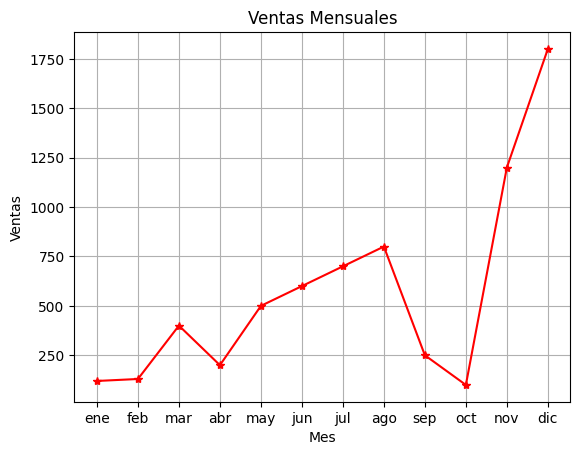

In [ ]:

#¿Qué es un line plot?


df3 = pd.DataFrame({
    "Mes": ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic" ],
    "Ventas": [120, 130, 400, 200, 500, 600, 700, 800, 250, 100, 1200, 1800]
})

plt.plot(df3["Mes"], df3["Ventas"], marker="*", color="red")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.title("Ventas Mensuales")
plt.grid(True)
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


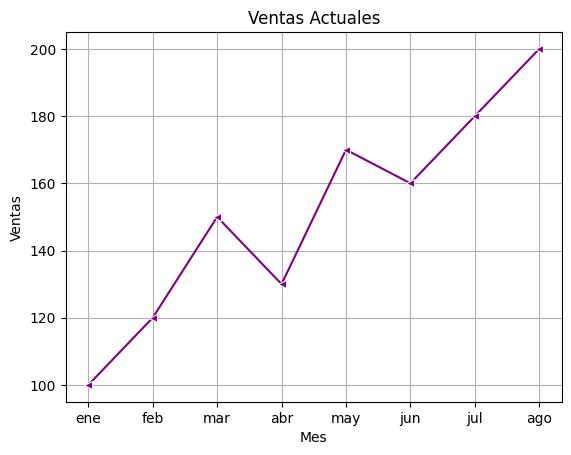

In [ ]:
# Datos de ejemplo
df5 = pd.DataFrame({
    "Mes": ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago"],
    "Ventas": [100, 120, 150, 130, 170, 160, 180,200]
})

# Gráfico de línea
sns.lineplot(x="Mes", y="Ventas", marker="<", color="purple", data=df5)
plt.title("Ventas Actuales")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

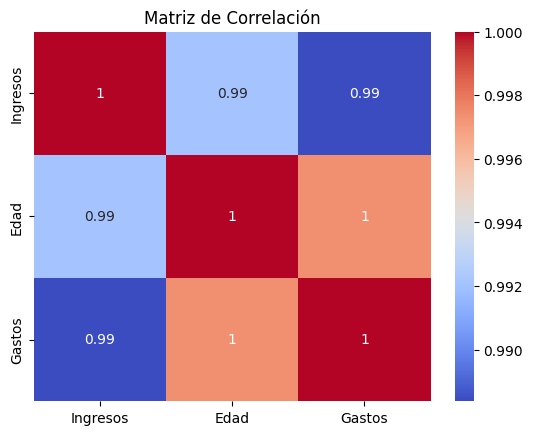

In [ ]:
#Heatmap con seaborn -


#datset ejemplo
df = pd.DataFrame({
    "Ingresos": [1200, 1300, 1500, 1600, 1700, 1750, 1900, 2000, 2100, 2500],
    "Edad": [20, 22, 25, 27, 30, 32, 35, 37, 40, 45],
    "Gastos": [500, 600, 700, 800, 1000, 1100, 1300, 1400, 1600, 1900]
})

#Calcular la correlación
correlacion = df.corr()
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

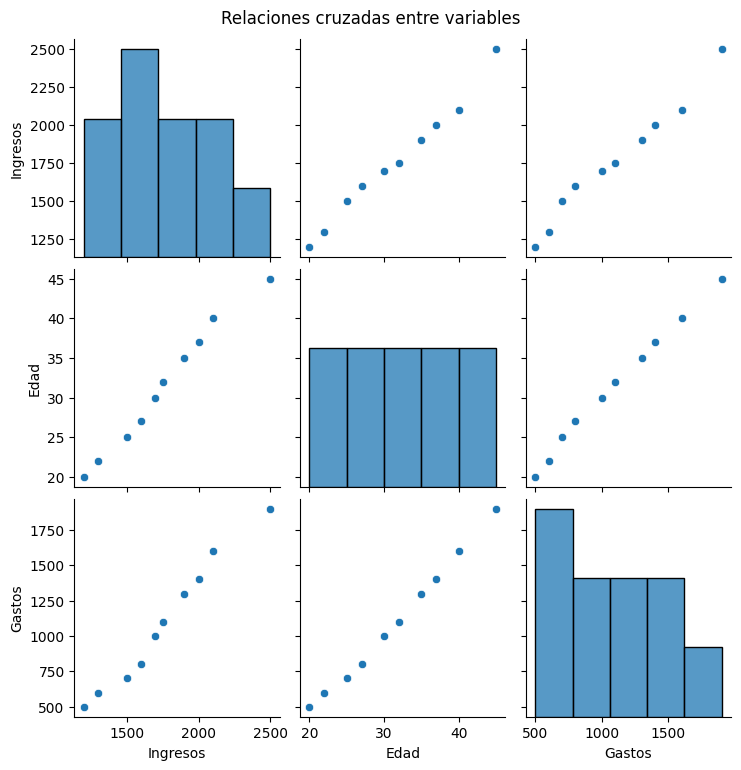

In [ ]:
#Pairplot con seaborn

#datset ejemplo
df = pd.DataFrame({
    "Ingresos": [1200, 1300, 1500, 1600, 1700, 1750, 1900, 2000, 2100, 2500],
    "Edad": [20, 22, 25, 27, 30, 32, 35, 37, 40, 45],
    "Gastos": [500, 600, 700, 800, 1000, 1100, 1300, 1400, 1600, 1900]
})


#crear pairplot

sns.pairplot(df)
plt.suptitle("Relaciones cruzadas entre variables", y=1.02)
plt.show()
#

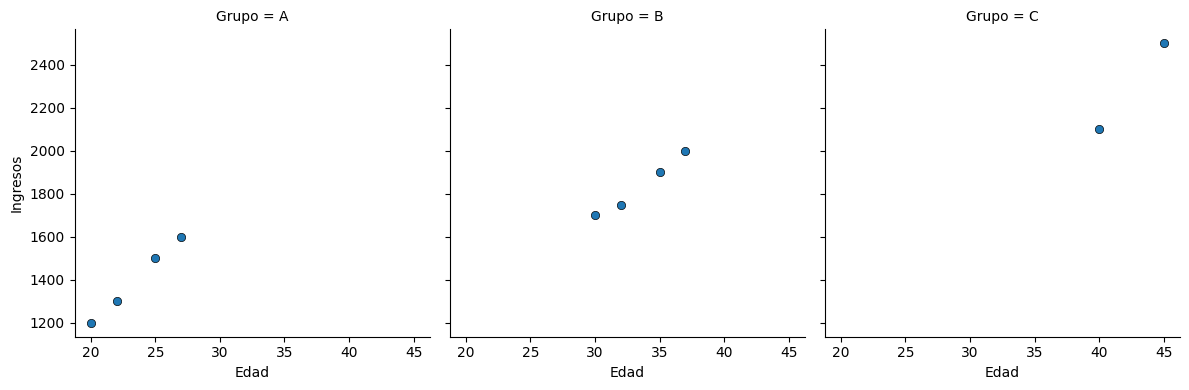

In [ ]:
#FacetGrid con seaborn

#datset ejemplo
df = pd.DataFrame({
    "Ingresos": [1200, 1300, 1500, 1600, 1700, 1750, 1900, 2000, 2100, 2500],
    "Edad": [20, 22, 25, 27, 30, 32, 35, 37, 40, 45],
    "Gastos": [500, 600, 700, 800, 1000, 1100, 1300, 1400, 1600, 1900],
    "Grupo": ["A", "A", "A", "A", "B", "B", "B", "B", "C", "C"]
})

g = sns.FacetGrid(df, col="Grupo", height=4)
g.map(sns.scatterplot, "Edad", "Ingresos", edgecolor="black")
plt.show()
#



In [ ]:
pip install plotly

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
import random


df3 = pd.DataFrame({
    "ciudad" : ["Bogotá", "Medellin", "Cali", "Barranquilla"],
    "ventas" : [150, 200, 130, 100]
})

fig = px.bar(df3, x="ciudad", y="ventas", color="ciudad", title="Ventas por ciudad")
fig.show()

In [ ]:
df_dispersion = pd.DataFrame({

   "Edad" : np.random.randint(18, 65, 100),
   "Ingresos" : np.random.randint(20000, 100000, 100)
})

fig2 = px.scatter(df_dispersion, x="Edad", y="Ingresos", color="Ingresos", title="relacion  de entre edad e ingresos ")
fig.show()

In [ ]:
df_dona = pd.DataFrame({
      "Categoria" : ["A", "B", "C", "D"],
      "Ventas" : [150, 200, 130, 100]
})

fig3 = px.pie(df_dona, values="Ventas", names="Categoria", title="Ventas por Categoria")
fig3.show()